In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =  pd.read_csv("Data/stud.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [11]:
for col in df.columns:
    print(f"{col}: {df[col].unique()} ")

gender: ['female' 'male'] 
race_ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E'] 
parental_level_of_education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school'] 
lunch: ['standard' 'free/reduced'] 
test_preparation_course: ['none' 'completed'] 
math_score: [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8] 
reading_score: [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40] 
writing_score: [ 74  88  93  

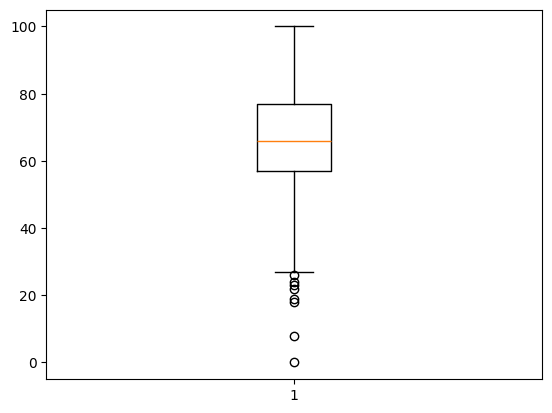

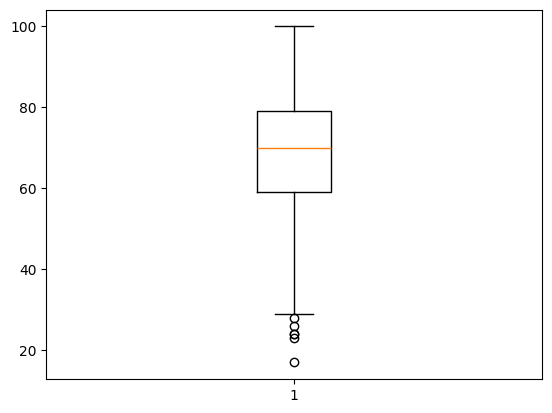

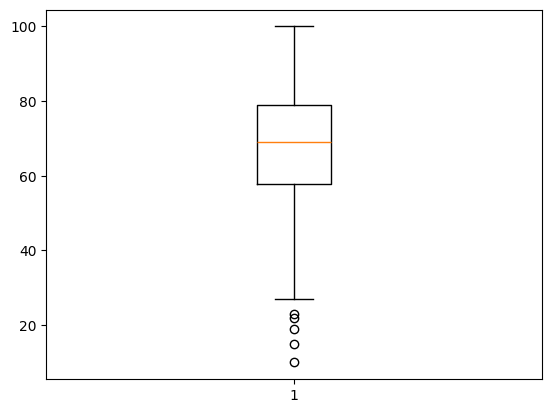

In [13]:
for col in df.columns:
    if df[col].dtype != 'object':
        plt.boxplot(x=df[col])
        plt.show()

In [14]:
# checking and removing outliers using IQR method
for col in df.columns:
    if df[col].dtype != 'object':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Outliers in {col}: {len(outliers)}")
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


Outliers in math_score: 8
Outliers in reading_score: 6
Outliers in writing_score: 0


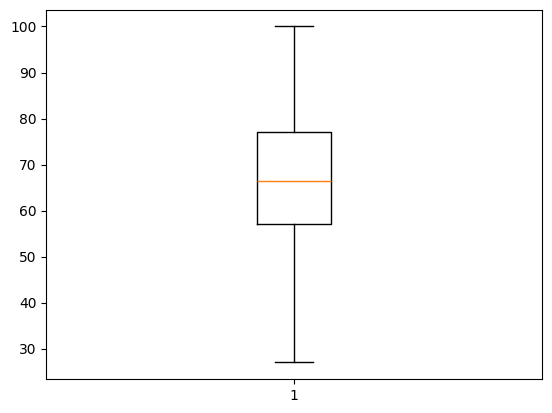

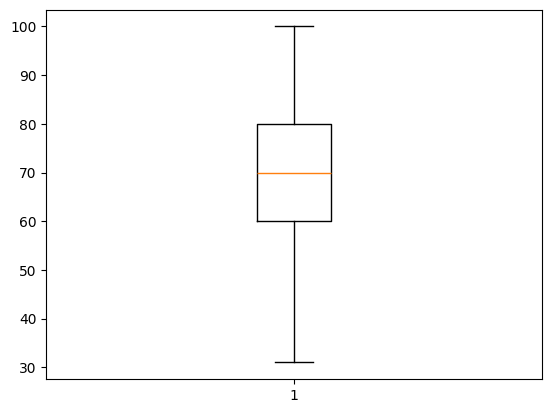

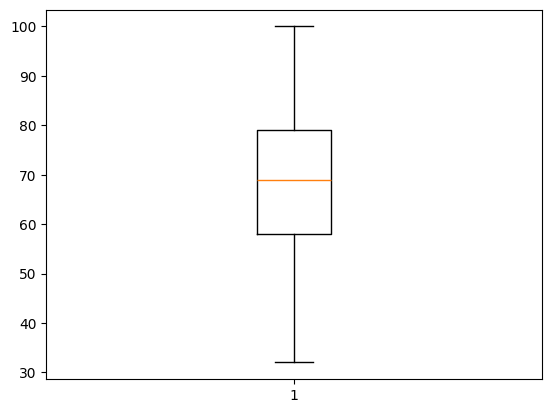

In [15]:
for col in df.columns:
    if df[col].dtype != 'object':
        plt.boxplot(x=df[col])
        plt.show()

In [16]:
df.describe()

,math_score,reading_score,writing_score
count,986.000000,986.000000,986.000000
mean,66.694726,69.723124,68.648073
std,14.340780,13.910716,14.427092
min,27.000000,31.000000,32.000000
25%,57.000000,60.000000,58.000000
50%,66.500000,70.000000,69.000000
75%,77.000000,80.000000,79.000000
max,100.000000,100.000000,100.000000


In [17]:
df.shape

(986, 8)

In [20]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [21]:
df['TotalScore'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['AverageScore'] = df['TotalScore'] / 3

In [22]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,TotalScore,AverageScore
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


Text(0.5, 1.0, 'Distribution of Total Scores')

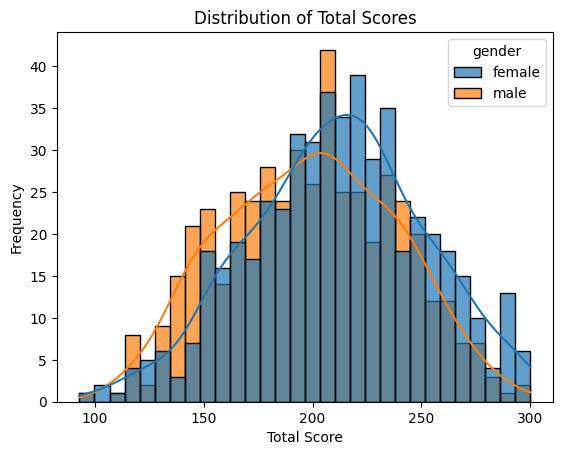

In [31]:
# plt.subplot(121)
sns.histplot(data=df, x='TotalScore', bins=30, color='blue', alpha=0.7, kde=True, hue='gender')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.title('Distribution of Total Scores')

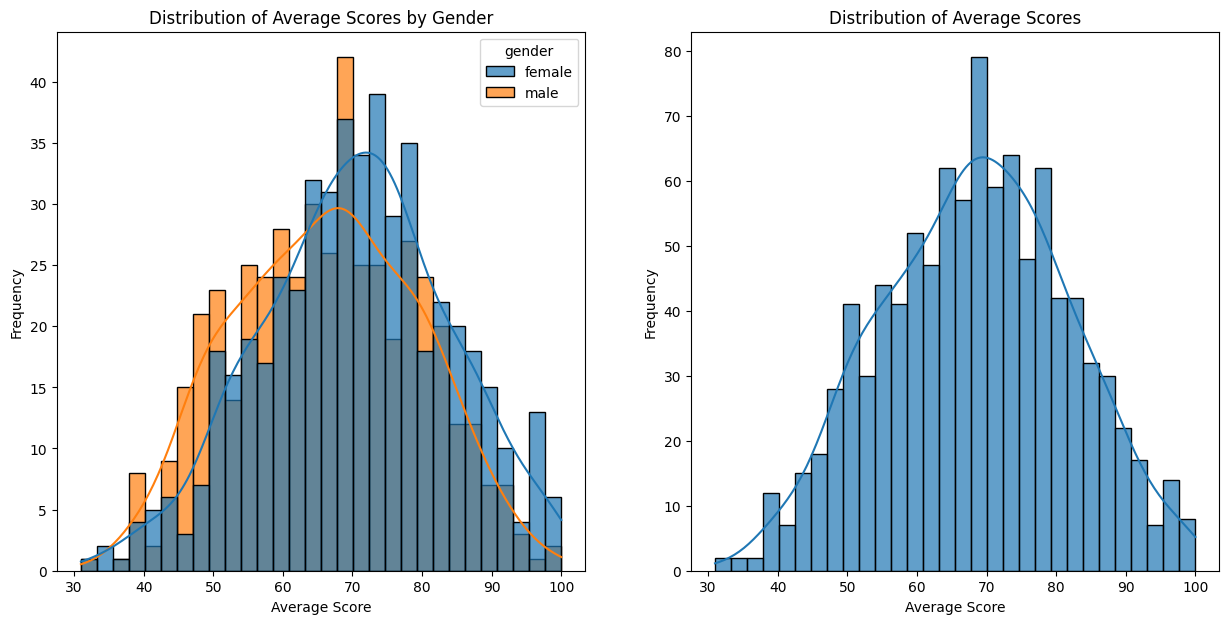

In [33]:
plt.subplots(1,2,figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df, x='AverageScore', bins=30, color='blue', alpha=0.7, kde=True, hue='gender')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.title('Distribution of Average Scores by Gender')

plt.subplot(122)
sns.histplot(data=df, x='AverageScore', bins=30, alpha=0.7, kde=True)
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.title('Distribution of Average Scores')
plt.tight_layout
plt.show()

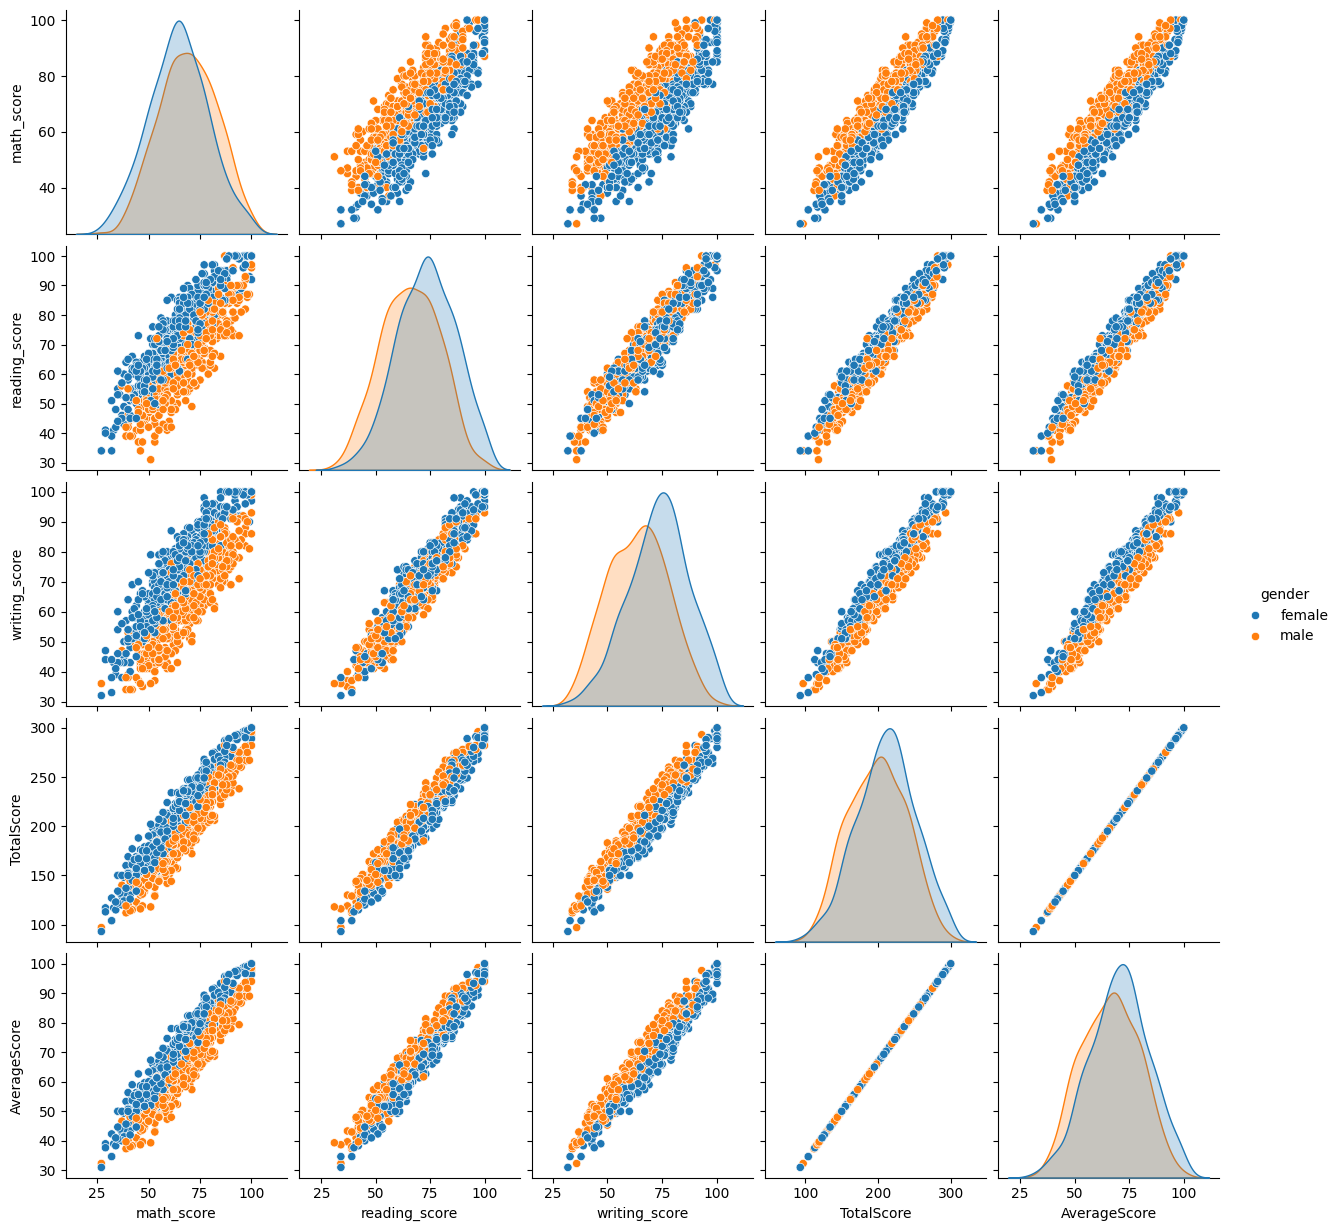

In [37]:
sns.pairplot(data=df,hue='gender')
plt.show()